# Chaîne OSF CAPC-AC — Notebook 00 · Fondations (phase P0)

**Objectif :** poser les bases qui rendent la chaîne *reproductible, traçable et vérifiable* (définition d'une prévision objective, Draft Framework §1.1) avant tout calcul scientifique.

| Étape du workflow | Ce que ce notebook montre | Module |
|---|---|---|
| E0 · Configuration | un cycle = un fichier YAML validé | `eccas_s2s.settings` |
| E0 · Provenance | chaque exécution écrit un journal et un manifeste | `eccas_s2s.provenance` |
| E2/E8 · Périodes | décades, mois, saisons d'une initialisation, pour la prévision **et** chaque année de hindcast | `eccas_s2s.core.periods` |
| E2 · Cumuls journaliers | la pluie de l'échéance +24 h est celle **du jour d'initialisation** | `eccas_s2s.core.daily` |
| E5d · Indicateurs agro | quels indicateurs de saison sont réalisables avec l'init. de septembre | `eccas_s2s.agro.calendars` |

Références : Draft Framework §3.1.8 (harmonisation temporelle), §3.1.10 (métadonnées, traçabilité), §4.3 (operational readiness) ; OMM-N° 1246 principe P1.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
CYCLE_FILE = REPO / "config" / "cycle_202609.yaml"
pd.set_option("display.width", 160)
print("dépôt :", REPO)

dépôt : /home/ludric/Downloads/SVM/Previsions_S2S/eccas-s2s


## 1. Un cycle = un fichier de configuration

Toute la chaîne lit **un seul fichier** `config/cycle_YYYYMM.yaml`, qui inclut trois fichiers partagés :

- `domains.yaml` : domaine CEEAC et sous-zones Nord / Équatoriale / Sud ;
- `thresholds.yaml` : percentiles par maille, seuils en mm, percentiles extrêmes de température ;
- `agro_calendars.yaml` : paramètres Liebmann repris de `seasonal_engine` v10.

`load_cycle` lit, fusionne et **valide** ces fichiers : une date d'initialisation qui n'est pas le 1er du mois ou une échelle inconnue provoquent une erreur explicite. Il calcule aussi l'empreinte SHA-256 de chaque fichier ; une prévision pourra ainsi toujours être rattachée à la configuration exacte qui l'a produite.

In [2]:
from eccas_s2s.settings import load_cycle

cfg = load_cycle(CYCLE_FILE)
print("cycle             :", cfg.name, "| id", cfg.cycle_id)
print("initialisation    :", cfg.init_date.date())
print("échelles          :", cfg.scales)
print("variables         :", cfg.variables)
print("ajustement C3S    :", cfg.reference_period("c3s_fit"))
print("normale observée  :", cfg.reference_period("obs_normal"), "→ seuils de catégories communs (D12)")
print("validation croisée:", cfg.cv_scheme)
print("hindcast C3S      :", cfg.c3s_hindcast_years[0], "→", cfg.c3s_hindcast_years[-1],
      f"({len(cfg.c3s_hindcast_years)} ans)")
pd.DataFrame([vars(m) for m in cfg.c3s_models.values()])

cycle             : OSF CAPC-AC — initialisation septembre 2026 | id 202609
initialisation    : 2026-09-01
échelles          : ['decade', 'month', 'season']
variables         : ['precip', 't2m', 'tmax', 'tmin']
ajustement C3S    : (1993, 2016)
normale observée  : (1991, 2020) → seuils de catégories communs (D12)
validation croisée: loyo
hindcast C3S      : 1993 → 2016 (24 ans)


,centre,system,label,max_lead_days
0,ecmwf,51,ECMWF SEAS5.1,215
1,ukmo,610,UKMO GloSea,215
2,meteo_france,9,Météo-France Sys 9,212
3,dwd,22,DWD GCFS2.2,181
4,cmcc,4,CMCC SPS4,184
5,eccc,5,ECCC GEM5.2-NEMO,214
6,bom,2,BoM ACCESS-S2,215


Les numéros de système C3S sont écrits **explicitement** dans la configuration du cycle (UKMO = 610 pour une initialisation en septembre 2026). Le code v10 les déduisait automatiquement ; les écrire dans le fichier les rend visibles et traçables. Chaque mois, ce tableau est vérifié en copiant le fichier du cycle précédent.

`max_lead_days` est l'horizon quotidien **effectivement reçu**, relevé au contrôle qualité des fichiers : DWD 181 jours (jusqu'au 28 février ; 184 demandés), CMCC 184, Météo-France 212 (215 demandés), les autres 214–215. Dans les hindcasts, les années dont la fenêtre contient un 29 février ont un jour de plus, puisque le modèle s'arrête à une date calendaire fixe.

## 2. Traçabilité : contexte d'exécution et manifeste

Chaque script s'exécute dans un `RunContext`. À la sortie, même en cas d'erreur, il écrit dans `OUTPUTS_OSF/runs/<run_id>/` :

- `run.log` : le journal horodaté ;
- `manifest.json` : la configuration complète et ses empreintes, le commit git (avec l'indication *dirty* si du code n'est pas commité), les versions des bibliothèques, les paramètres, ainsi que les **fichiers lus et produits** (taille, date, SHA-256).

`archive_run` copie ensuite un run terminé dans `ARCHIVE_OSF/AAAA/MM/<run_id>/` sans jamais écraser une archive existante. La vérification en temps réel (E9) relira cette archive.

In [3]:
from eccas_s2s.provenance import RunContext

with RunContext(cfg, step="notebook00_demo") as ctx:
    ctx.record_parameter("objet", "démonstration du manifeste")
    ctx.record_input(CYCLE_FILE, role="configuration")

manifest = json.loads((ctx.run_dir / "manifest.json").read_text())
print("run_id :", manifest["run_id"], "| statut :", manifest["status"])
print("code   :", manifest["code"])
print("entrées:", [(e["role"], Path(e["path"]).name, e["sha256"][:12]) for e in manifest["inputs"]])
print("clés du manifeste :", list(manifest))

2026-09-19 13:13:11 | INFO    | === début notebook00_demo | cycle 202609 | run 202609_notebook00_demo_20260919T121311Z ===


2026-09-19 13:13:11 | INFO    | entrée [configuration] /home/ludric/Downloads/SVM/Previsions_S2S/eccas-s2s/config/cycle_202609.yaml


2026-09-19 13:13:11 | INFO    | === fin notebook00_demo | statut success | manifeste /home/ludric/Downloads/SVM/Previsions_S2S/OUTPUTS_OSF/runs/202609_notebook00_demo_20260919T121311Z/manifest.json ===


run_id : 202609_notebook00_demo_20260919T121311Z | statut : success
code   : {'eccas_s2s_version': '0.1.0', 'git': {'commit': '54ed4275a53f9c095cd664bef0f73daeb63822f3', 'branch': 'osf/p0-fondations', 'dirty': True}}
entrées: [('configuration', 'cycle_202609.yaml', '4b4fc9f6b234')]
clés du manifeste : ['run_id', 'step', 'status', 'error', 'started_utc', 'duration_s', 'cycle', 'code', 'environment', 'parameters', 'inputs', 'outputs', 'warnings']


> **Bonne pratique opérationnelle :** une prévision émise doit provenir d'un code **commité** (`dirty: false`). Pendant le développement, `dirty: true` est normal ; le manifeste le signale.

## 3. Les périodes cibles d'une initialisation

Chaque période (décade, mois, saison) est définie **par rapport au mois d'initialisation** (`month_offset`). On obtient ainsi ses dates pour l'année de prévision **et** pour chaque année de hindcast, qui démarre le même jour :

- décades D1 = 1–10, D2 = 11–20, D3 = 21 → fin du mois (8 à 11 jours) ;
- saisons = 3 mois consécutifs, nommées par leurs initiales (SON, OND, NDJ, DJF) ;
- on ne garde que les périodes **complètes** dans l'horizon. Une période partielle mélangerait des cumuls de longueurs différentes et fausserait les comparaisons avec les observations.

L'horizon commun est celui du modèle le plus court (181 jours pour DWD, soit jusqu'au 28 février 2027), afin que **tous les modèles** couvrent chaque période du multi-modèle.

In [4]:
from eccas_s2s.core.periods import build_periods, periods_table

horizon_common = min(m.max_lead_days for m in cfg.c3s_models.values())
periods = build_periods(cfg.init_date, horizon_common, scales=cfg.scales)
tab = periods_table(periods, cfg.init_date.year)
print(f"horizon commun : {horizon_common} jours → dernier jour prévu",
      (cfg.init_date + pd.Timedelta(days=horizon_common - 1)).date())
print(tab["scale"].value_counts().to_dict())
tab.query("scale != 'decade'")

horizon commun : 181 jours → dernier jour prévu 2027-02-28
{'decade': 18, 'month': 6, 'season': 4}


,scale,key,label,start,end,n_days,lead_month,first_lead_day,last_lead_day
18,month,month_m0,2026-09,2026-09-01,2026-09-30,30,0,0,29
19,month,month_m1,2026-10,2026-10-01,2026-10-31,31,1,30,60
20,month,month_m2,2026-11,2026-11-01,2026-11-30,30,2,61,90
21,month,month_m3,2026-12,2026-12-01,2026-12-31,31,3,91,121
22,month,month_m4,2027-01,2027-01-01,2027-01-31,31,4,122,152
23,month,month_m5,2027-02,2027-02-01,2027-02-28,28,5,153,180
24,season,season_m0,SON 2026,2026-09-01,2026-11-30,91,0,0,90
25,season,season_m1,OND 2026,2026-10-01,2026-12-31,92,1,30,121
26,season,season_m2,NDJ 2026-27,2026-11-01,2027-01-31,92,2,61,152
27,season,season_m3,DJF 2026-27,2026-12-01,2027-02-28,90,3,91,180


In [5]:
tab.query("scale == 'decade'").head(6)

,scale,key,label,start,end,n_days,lead_month,first_lead_day,last_lead_day
0,decade,decade_m0_d1,2026-09-D1,2026-09-01,2026-09-10,10,0,0,9
1,decade,decade_m0_d2,2026-09-D2,2026-09-11,2026-09-20,10,0,10,19
2,decade,decade_m0_d3,2026-09-D3,2026-09-21,2026-09-30,10,0,20,29
3,decade,decade_m1_d1,2026-10-D1,2026-10-01,2026-10-10,10,1,30,39
4,decade,decade_m1_d2,2026-10-D2,2026-10-11,2026-10-20,10,1,40,49
5,decade,decade_m1_d3,2026-10-D3,2026-10-21,2026-10-31,11,1,50,60


**Années bissextiles.** La 3ᵉ décade de février a 8 jours en 2027 mais 9 jours en 1996, qui est une année de hindcast. La même période (`decade_m5_d3`) correspond donc à des jours d'échéance différents selon l'année, et le code le gère :

In [6]:
feb_d3 = [p for p in periods if p.key == "decade_m5_d3"][0]
pd.DataFrame([{"année d'init.": y, "dates": f"{feb_d3.dates(y)[0].date()} → {feb_d3.dates(y)[1].date()}",
               "jours": feb_d3.n_days(y), "jours d'échéance": feb_d3.day_slice(y)} for y in (1995, 2026)])

,année d'init.,dates,jours,jours d'échéance
0,1995,1996-02-21 → 1996-02-29,9,"(173, 181)"
1,2026,2027-02-21 → 2027-02-28,8,"(173, 180)"


## 4. Attribution des cumuls journaliers : correction d'un décalage d'un jour

Dans `seasonal-original-single-levels`, la pluie `tp` est **cumulée depuis l'initialisation**. Le champ de l'échéance +24 h est daté du **2** à 00 UTC, mais il contient la pluie tombée **le 1er**. La pluie du jour d'échéance *i* (0 = jour d'initialisation) vaut donc :

$$ \text{pluie}[i] = tp(i+1\ \text{j}) - tp(i\ \text{j}), \qquad tp(0) = 0 $$

La chaîne actuelle rangeait chaque cumul journalier à sa date de validité : sa « 1ʳᵉ décade » allait du 2 au 11 du mois. La nouvelle chaîne range chaque cumul au jour où la pluie est tombée, comme CHIRPS. Sans cette correction, la calibration comparerait des fenêtres décalées d'un jour entre modèle et observation.

**Incréments négatifs.** Le codage GRIB arrondit les cumuls ; la différence entre deux jours peut donc être très légèrement négative. Sur ce fichier, 0,26 % des valeurs le sont, avec un minimum de −0,13 mm et une médiane de −0,03 mm. Elles sont mises à 0 et leur nombre est conservé dans les attributs.

Illustration avec le fichier ECMWF **d'août 2026** déjà disponible (celui de septembre est en cours de téléchargement). Point choisi : Yaoundé (3,87° N ; 11,52° E).

In [7]:
from eccas_s2s.io.c3s_read import open_c3s_grib, load_c3s_precip_daily
from eccas_s2s.core.daily import aggregate_periods
from eccas_s2s.core.periods import Period

AUG = Path("/home/ludric/Downloads/SVM/Previsions_S2S/DOWNLOAD_C3S_DATA/grib_files/ecmwf_seasonal_forecast_2026_08_01.grib")
raw = open_c3s_grib(AUG)
print("échéances :", (raw.step.values[:3] / np.timedelta64(1, "D")).astype(int), "jours ...")
print("dates de validité :", [str(v)[:13] for v in raw.valid_time.values[:3]])

daily = load_c3s_precip_daily(AUG)
print("\nstructure OSF :", dict(daily.sizes))
print("jour d'échéance 0 =", pd.Timestamp(2026, 8, 1).date(), "| valeurs négatives mises à 0 :", daily.attrs["n_negative_clipped"])

échéances : [1 2 3] jours ...
dates de validité : ['2026-08-02T00', '2026-08-03T00', '2026-08-04T00']



structure OSF : {'year': 1, 'number': 51, 'lead_day': 215, 'latitude': 55, 'longitude': 45}
jour d'échéance 0 = 2026-08-01 | valeurs négatives mises à 0 : 71191


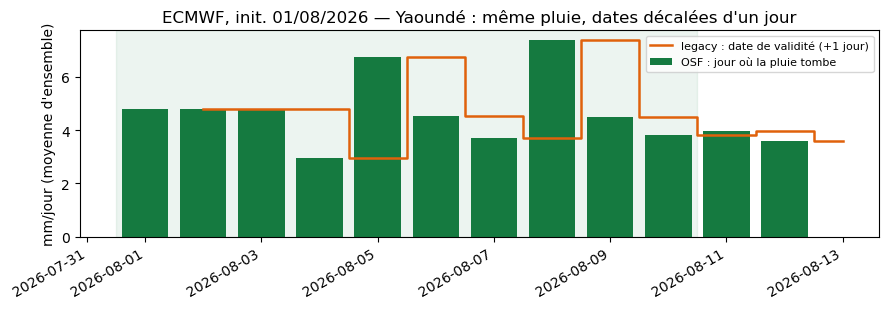

In [8]:
pt = dict(latitude=3.87, longitude=11.52, method="nearest")
ens_mean = daily.sel(**pt).isel(year=0).mean("number").values[:12]
days_new = pd.date_range("2026-08-01", periods=12)
days_old = pd.date_range("2026-08-02", periods=12)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(days_new, ens_mean, width=0.8, color="#157A40", label="OSF : jour où la pluie tombe")
ax.step(days_old, ens_mean, where="mid", color="#E0610B", lw=1.8, label="legacy : date de validité (+1 jour)")
ax.axvspan(pd.Timestamp("2026-07-31 12:00"), pd.Timestamp("2026-08-10 12:00"), color="#157A40", alpha=0.08)
ax.set_ylabel("mm/jour (moyenne d'ensemble)")
ax.set_title("ECMWF, init. 01/08/2026 — Yaoundé : même pluie, dates décalées d'un jour")
ax.legend(loc="upper right", fontsize=8); fig.autofmt_xdate(); plt.tight_layout()

In [9]:
d1 = aggregate_periods(daily, [Period("decade", 8, 0, decade=1)], how="sum")
from eccas_s2s.core.processing import decumulate_precip_to_mm
legacy = decumulate_precip_to_mm(raw)["tp_daily"].swap_dims({"step": "valid_time"})
old_d1 = legacy.sel(valid_time=slice("2026-08-01", "2026-08-10")).sum("valid_time")   # ce que produisait l'ancienne « décade 1-10 »
new_d1 = d1.isel(year=0, period=0)

cmp = pd.DataFrame({
    "OSF D1 (pluie du 1 au 10)": [float(new_d1.sel(**pt).mean("number"))],
    "legacy « 1–10 » (pluie du 1 au 9)*": [float(old_d1.sel(**pt).mean("number"))],
}, index=["Yaoundé, mm"]).round(1)
diff = (new_d1 - old_d1).mean("number")
print("écart moyen absolu sur le domaine (mm) :", float(abs(diff).mean()).__round__(2))
cmp

écart moyen absolu sur le domaine (mm) : 1.95


,OSF D1 (pluie du 1 au 10),legacy « 1–10 » (pluie du 1 au 9)*
"Yaoundé, mm",48.0,44.2


\* L'ancien calcul « 1–10 » sommait les cumuls datés du 2 au 10 août, c'est-à-dire **9 jours** de pluie (du 1er au 9 août), car aucun cumul n'est daté du 1er. Les décades suivantes contenaient 10 jours, mais décalés d'un jour. Le test `test_equivalence_with_legacy_convention_on_real_grib` vérifie que la nouvelle décade du 1er au 10 est **exactement** l'ancien cumul sur les dates de validité du 2 au 11 : seules les dates changent, les quantités sont identiques.

## 5. Indicateurs de saison réalisables avec l'initialisation de septembre

Règle retenue le 18/09/2026 : un indicateur (début ou fin de saison, séquences sèches/humides) n'est produit pour une initialisation que si **toute sa fenêtre de référence** est dans la prévision. Une fenêtre déjà commencée n'est **pas** complétée avec des observations. Les scripts de ces indicateurs seront tout de même développés et testés ; ils tourneront avec les initialisations recommandées par v10.

In [10]:
from eccas_s2s.agro.calendars import load_agro_products, feasibility_table

products = load_agro_products(cfg.agro_calendars)
feas = feasibility_table(products, cfg.init_date,
                         {f"tous modèles ({horizon_common} j)": horizon_common, "modèles longs (215 j)": 215})
feas

,product,zone,metric,window_start,window_end,recommended_init,tous modèles (181 j),modèles longs (215 j)
0,north_onset,north,onset,2027-02-01,2027-07-31,2,au-delà de l'horizon,au-delà de l'horizon
1,north_cessation,north,cessation,2026-06-01,2026-11-30,6,fenêtre déjà commencée,fenêtre déjà commencée
2,equatorial_mam,equatorial,both,2027-01-01,2027-07-15,1,au-delà de l'horizon,au-delà de l'horizon
3,equatorial_son,equatorial,both,2026-07-01,2027-01-15,7,fenêtre déjà commencée,fenêtre déjà commencée
4,south_onset,south,onset,2026-08-01,2027-01-31,8,fenêtre déjà commencée,fenêtre déjà commencée
5,south_cessation,south,cessation,2026-12-01,2027-05-31,12,au-delà de l'horizon,au-delà de l'horizon
6,ceeac_djf,ceeac,seasonal,2026-12-01,2027-02-28,10,réalisable,réalisable
7,ceeac_mam,ceeac,seasonal,2027-03-01,2027-05-31,1,au-delà de l'horizon,au-delà de l'horizon
8,ceeac_jja,ceeac,seasonal,2027-06-01,2027-08-31,4,au-delà de l'horizon,au-delà de l'horizon
9,ceeac_aso,ceeac,seasonal,2026-08-01,2026-10-31,6,fenêtre déjà commencée,fenêtre déjà commencée


**Lecture :** avec l'initialisation du 1er septembre 2026, seules les saisons fixes **SON, OND, NDJ et DJF** sont réalisables (séquences sèches/humides maximales et leurs dates). Les autres indicateurs ont une fenêtre soit déjà commencée (`south_onset`, `equatorial_son`, `north_cessation`, `ceeac_aso`), soit au-delà de l'horizon. Ils seront produits avec leurs propres initialisations (colonne `recommended_init`).

## 6. Suite

| Phase | Notebook | Contenu |
|---|---|---|
| P1 | `01_observations.ipynb` | CHIRPS : contrôle qualité, agrégation décade/mois/saison, percentiles 1991–2020 par maille |
| P1 | `02_modeles_c3s.ipynb` | Prévisions et hindcasts de septembre 2026 → cumuls par période, contrôle qualité |
| P2 | `04_skill_brut.ipynb` | Scores LOYO des modèles bruts |

Les tests de cette phase sont dans `tests/test_osf_p0.py` (`pytest -q`).